In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [180]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [129]:
df = pd.get_dummies(df, columns=['sex','smoker','region'],dtype=int, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [130]:
df.corr()['charges'].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64

### Let's apply RidgeCV model with chosen degree

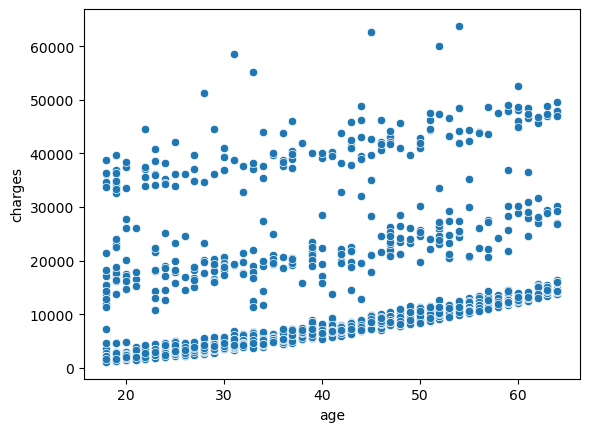

In [131]:
sns.scatterplot(df, x='age', y='charges');

In [132]:
X = df.drop('charges', axis=1)
y = np.log(df['charges']) # as we saw in last LR model, the model is not perfectly linear so we get the log of values

In [133]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)
polynomial_features = polynomial_converter.fit_transform(X)

In [134]:
X_train, X_test, y_train, y_test = train_test_split(polynomial_features, y, test_size=0.3, random_state=101)

In [135]:
from sklearn.linear_model import RidgeCV

In [136]:
R_cv_model = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000], scoring='neg_mean_absolute_error')

In [138]:
R_cv_model.fit(X_train,y_train)

RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000], cv=5,
        scoring='neg_mean_absolute_error')

In [139]:
R_cv_model.alpha_

1.0

In [140]:
y_preds = R_cv_model.predict(X_test)

In [141]:
mean_absolute_error(y_test, y_preds)

0.20313723194347982

In [142]:
np.sqrt(mean_squared_error(y_test,y_preds))

0.34320964008550114

In [143]:
r2_score(y_test,y_preds)

0.8580354959265608

In [149]:
final_model = R_cv_model.fit(polynomial_features,y)

In [148]:
from joblib import dump,load

In [150]:
dump(final_model, 'RidgeCV_insurnce_cost_prediction.joblib')

['RidgeCV_insurnce_cost_prediction.joblib']

In [151]:
loaded_model = load('RidgeCV_insurnce_cost_prediction.joblib')

In [152]:
loaded_model.coef_

array([ 5.56787514e-02,  4.43164840e-02,  3.43242991e-01, -1.87335480e-01,
        6.12085486e-01, -1.12734679e-02, -5.33354157e-02, -1.17404071e-01,
       -1.77283522e-04, -1.34134937e-04, -4.26512406e-03,  4.56901852e-03,
       -3.24076395e-02,  2.84894301e-03,  8.01686786e-03,  7.85663665e-03,
       -5.10225607e-04,  4.29333022e-05,  2.55975920e-03,  5.19624789e-02,
       -7.09062747e-03, -1.18572652e-02, -8.04834832e-03, -1.63276949e-02,
        2.85681791e-03, -1.28178258e-01,  1.72279115e-02, -2.08804655e-04,
       -2.12103443e-02, -1.87335480e-01,  8.55208150e-02,  4.02859913e-02,
        7.10341270e-03, -4.42304304e-03,  6.12085486e-01,  6.53040625e-02,
        7.37146590e-02,  1.87988450e-01, -1.12734679e-02,  0.00000000e+00,
        0.00000000e+00, -5.33354157e-02,  0.00000000e+00, -1.17404071e-01])

In [154]:
# Let's pick up one row and check our model if it predict well or not

X.iloc[155]

age                 44.00
bmi                 39.52
children             0.00
sex_male             1.00
smoker_yes           0.00
region_northwest     1.00
region_southeast     0.00
region_southwest     0.00
Name: 155, dtype: float64

In [159]:
new_customer = [[44,39,0,1,0,1,0,0]]

In [160]:
# we must transform the raw data into a polynomial feature data

transformed_data = polynomial_converter.transform(new_customer)

In [161]:
transformed_data

array([[4.400e+01, 3.900e+01, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.936e+03, 1.716e+03, 0.000e+00, 4.400e+01,
        0.000e+00, 4.400e+01, 0.000e+00, 0.000e+00, 1.521e+03, 0.000e+00,
        3.900e+01, 0.000e+00, 3.900e+01, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00]])

In [163]:
charge_prediction = loaded_model.predict(transformed_data)
charge_prediction # the output is a log value, we need to transform it to original value

array([8.85590774])

#### Convert back to the original charges from log type

In [164]:
original_charge_value = np.exp(loaded_model.predict(transformed_data))
original_charge_value

array([7015.71381628])

#### let's match with the original valuein row 155

In [167]:
df.iloc[155]['charges']

6948.7008

In [ ]:
We now see how our new model perfectly predict the charges with lower error than linear regression model

# Perfect